In [60]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [61]:
df=pd.read_csv('ghs-2022-person-v1.csv', encoding='cp1252')

In [62]:
df.head()

,uqnr,personnr,psu,prov,Four_by_Four,Sex,age,age_grp1,Population,Languages,...,sevdisab,geotype,metro_code,metro,stratum,lab_salary,employ_Status1,employ_Status2,rotation,person_wgt
0,160100090000003901,1,16010009000,Western Cape,Yes,Male,79,75+,White,Afrikaans,...,Not disabled,3,WC – Non-metro,Non-metro,10301,Unspecified,Employed,Employed,Quarter 3,638.501583
1,160100090000003901,2,16010009000,Western Cape,Yes,Female,76,75+,White,Afrikaans,...,Not disabled,3,WC – Non-metro,Non-metro,10301,Not applicable,Unspecified,Not economically active,Quarter 3,638.501583
2,160100090000007201,1,16010009000,Western Cape,Yes,Male,31,30-34,Coloured,Afrikaans,...,Not disabled,3,WC – Non-metro,Non-metro,10301,3929,Employed,Employed,Quarter 3,1302.069729
3,160100090000007201,2,16010009000,Western Cape,Yes,Female,34,30-34,Coloured,Afrikaans,...,Not disabled,3,WC – Non-metro,Non-metro,10301,Not applicable,Unspecified,Not economically active,Quarter 3,1302.069729
4,160100090000007201,3,16010009000,Western Cape,Yes,Male,12,10-14,Coloured,Afrikaans,...,Not disabled,3,WC – Non-metro,Non-metro,10301,Not applicable,Not applicable,Not applicable,Quarter 3,1302.069729


In [63]:
df.tail()

,uqnr,personnr,psu,prov,Four_by_Four,Sex,age,age_grp1,Population,Languages,...,sevdisab,geotype,metro_code,metro,stratum,lab_salary,employ_Status1,employ_Status2,rotation,person_wgt
66139,987106920000053601,1,98710692000,Limpopo,Yes,Female,35,35-39,African/Black,Sepedi,...,Not disabled,2,LP – Non-metro,Non-metro,90401,Not applicable,Unspecified,Not economically active,Quarter 1,1228.809184
66140,987106920000053601,2,98710692000,Limpopo,Yes,Male,11,10-14,African/Black,Sepedi,...,Not disabled,2,LP – Non-metro,Non-metro,90401,Not applicable,Not applicable,Not applicable,Quarter 1,1228.809184
66141,987106920000053601,3,98710692000,Limpopo,Yes,Female,7,05-09,African/Black,Sepedi,...,Not disabled,2,LP – Non-metro,Non-metro,90401,Not applicable,Not applicable,Not applicable,Quarter 1,1228.809184
66142,987106920000053601,4,98710692000,Limpopo,Yes,Female,3,00-04,African/Black,Sepedi,...,Not disabled,2,LP – Non-metro,Non-metro,90401,Not applicable,Not applicable,Not applicable,Quarter 1,1228.809184
66143,987106920000053601,5,98710692000,Limpopo,Yes,Female,1,00-04,African/Black,Sepedi,...,Not disabled,2,LP – Non-metro,Non-metro,90401,Not applicable,Not applicable,Not applicable,Quarter 1,1228.809184


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66144 entries, 0 to 66143
Columns: 112 entries, uqnr to person_wgt
dtypes: float64(1), int64(6), object(105)
memory usage: 56.5+ MB


In [65]:
df.columns

Index(['uqnr', 'personnr', 'psu', 'prov', 'Four_by_Four', 'Sex', 'age',
       'age_grp1', 'Population', 'Languages',
       ...
       'sevdisab', 'geotype', 'metro_code', 'metro', 'stratum', 'lab_salary',
       'employ_Status1', 'employ_Status2', 'rotation', 'person_wgt'],
      dtype='object', length=112)

In [66]:
df = df[df['lab_salary'].notna()]

In [67]:
df['lab_salary'] = pd.to_numeric(df['lab_salary'], errors='coerce')
df['person_wgt'] = pd.to_numeric(df['person_wgt'], errors='coerce')

In [68]:
df = df.dropna(subset=['lab_salary', 'person_wgt', 'Population'])

<b> Income gap

In [69]:
income_by_race = df.groupby('Population').apply(
    lambda x: np.sum(x['lab_salary'] * x['person_wgt']) / np.sum(x['person_wgt'])
).sort_values(ascending=False)
print("\nIncome by Race:\n", income_by_race)


Income by Race:
 Population
White            31534.809689
Indian/Asian     21837.124504
Coloured         10595.515507
African/Black     8304.966446
dtype: float64


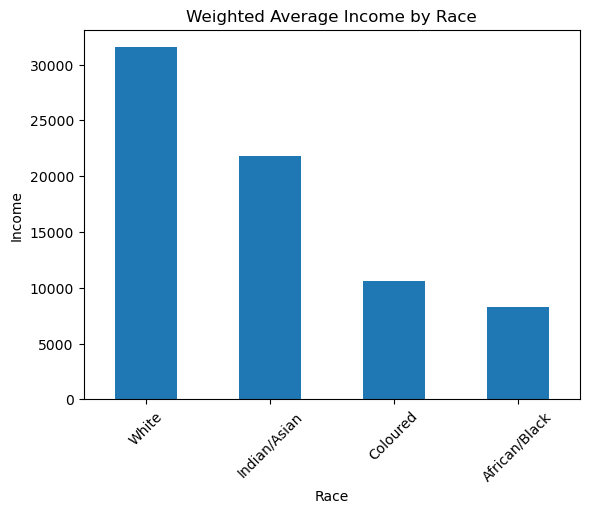

In [70]:
income_by_race.plot(kind='bar')
plt.title("Weighted Average Income by Race")
plt.ylabel("Income")
plt.xlabel("Race")
plt.xticks(rotation=45)
plt.show()

<b> Spatial segregation

In [71]:
spatial_dist = df.groupby(['metro', 'Population']).apply(
    lambda x: np.sum(x['person_wgt'])
).reset_index(name='population')

In [72]:
spatial_dist['total'] = spatial_dist.groupby('metro')['population'].transform('sum')
spatial_dist['percentage'] = spatial_dist['population'] / spatial_dist['total']

In [73]:
pivot_spatial = spatial_dist.pivot(index='metro', columns='Population', values='percentage')
print("\nSpatial Distribution (Metro %):\n", pivot_spatial)


Spatial Distribution (Metro %):
 Population  African/Black  Coloured  Indian/Asian     White
metro                                                      
Metro            0.715895  0.090154      0.057522  0.136429
Non-metro        0.814502  0.092427      0.010807  0.082263


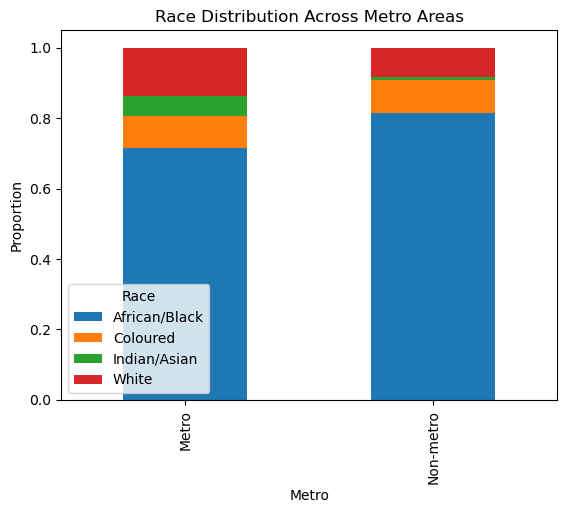

In [74]:
pivot_spatial.plot(kind='bar', stacked=True)
plt.title("Race Distribution Across Metro Areas")
plt.ylabel("Proportion")
plt.xlabel("Metro")
plt.legend(title="Race")
plt.show()

<b> Employment gap

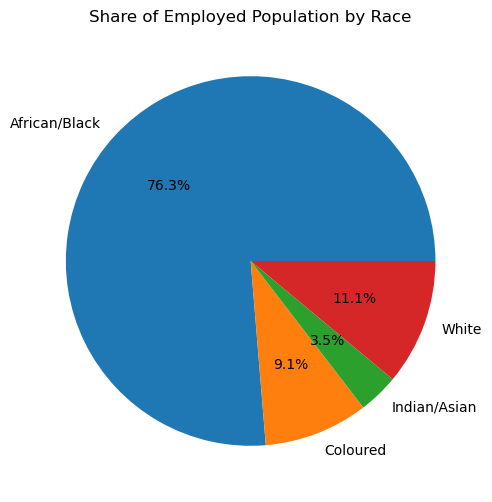

In [75]:
pop_share = df.groupby('Population')['person_wgt'].sum()
pop_share.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Share of Employed Population by Race")
plt.ylabel("")
plt.show()

<b> Income gap within provinces

In [76]:
df = df.dropna(subset=['lab_salary', 'person_wgt'])
df['weighted_income'] = df['lab_salary'] * df['person_wgt']
income_gap = df.groupby(['prov', 'Population']).apply(
    lambda x: np.sum(x['weighted_income']) / np.sum(x['person_wgt'])
).reset_index(name='avg_income')
print(income_gap)

             prov     Population    avg_income
0    Eastern Cape  African/Black   6470.024067
1    Eastern Cape       Coloured   7287.411604
2    Eastern Cape   Indian/Asian   6014.682534
3    Eastern Cape          White  19547.866356
4      Free State  African/Black   8272.110109
5      Free State       Coloured   6513.066679
6      Free State   Indian/Asian   6868.768931
7      Free State          White  45772.879987
8         Gauteng  African/Black   9433.809979
9         Gauteng       Coloured  18605.522462
10        Gauteng   Indian/Asian  24261.670780
11        Gauteng          White  31717.099712
12  KwaZulu-Natal  African/Black   7808.268310
13  KwaZulu-Natal       Coloured  18457.538182
14  KwaZulu-Natal   Indian/Asian  22034.848221
15  KwaZulu-Natal          White  30865.084701
16        Limpopo  African/Black   8737.023084
17        Limpopo       Coloured  36736.145981
18        Limpopo   Indian/Asian  23056.885942
19        Limpopo          White  35145.837901
20     Mpumal

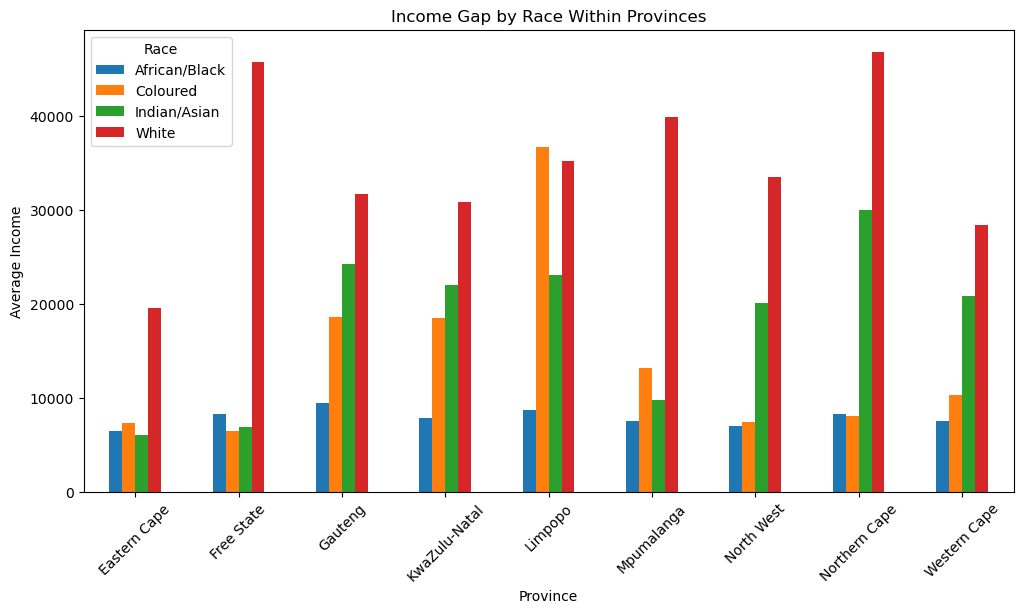

In [77]:
pivot_income = income_gap.pivot(index='prov', columns='Population', values='avg_income')
pivot_income.plot(kind='bar', figsize=(12,6))
plt.title("Income Gap by Race Within Provinces")
plt.ylabel("Average Income")
plt.xlabel("Province")
plt.xticks(rotation=45)
plt.legend(title="Race")
plt.show()

<b> Spatial inequality score

In [78]:
national_avg = (df['lab_salary'] * df['person_wgt']).sum() / df['person_wgt'].sum()
prov_avg = df.groupby('prov').apply(
    lambda x: (x['lab_salary'] * x['person_wgt']).sum() / x['person_wgt'].sum()
)
spatial_gap = (prov_avg - national_avg) / national_avg
spatial_gap = spatial_gap.reset_index(name='relative_gap')
print(spatial_gap)

            prov  relative_gap
0   Eastern Cape     -0.320528
1     Free State      0.136655
2        Gauteng      0.109918
3  KwaZulu-Natal     -0.065447
4        Limpopo     -0.156100
5     Mpumalanga     -0.155722
6     North West     -0.180787
7  Northern Cape      0.192455
8   Western Cape      0.164284


<b> Gini coefficient

In [79]:
def weighted_gini(x, w):
    # Sort by income
    sorted_idx = np.argsort(x)
    x = x[sorted_idx]
    w = w[sorted_idx]
    cumw = np.cumsum(w)
    cumxw = np.cumsum(x * w)
    return 1 - 2 * np.sum(cumxw * w) / (cumxw[-1] * cumw[-1])

In [80]:
gini_race = df.groupby('Population').apply(
    lambda x: weighted_gini(x['lab_salary'].values, x['person_wgt'].values)
).reset_index(name='gini')
print(gini_race)

      Population      gini
0  African/Black  0.566996
1       Coloured  0.508236
2   Indian/Asian  0.450978
3          White  0.507373


In [81]:
gini_prov = df.groupby('prov').apply(
    lambda x: weighted_gini(x['lab_salary'].values, x['person_wgt'].values)
).reset_index(name='gini')
print(gini_prov)

            prov      gini
0   Eastern Cape  0.590708
1     Free State  0.702683
2        Gauteng  0.579662
3  KwaZulu-Natal  0.582706
4        Limpopo  0.638245
5     Mpumalanga  0.632629
6     North West  0.620445
7  Northern Cape  0.699268
8   Western Cape  0.542265


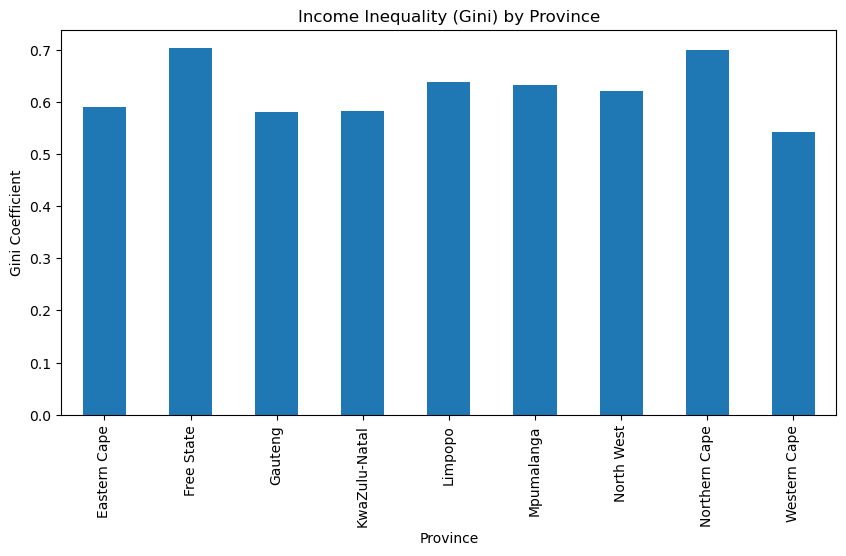

In [82]:
gini_prov.set_index('prov')['gini'].plot(kind='bar', figsize=(10,5))
plt.title("Income Inequality (Gini) by Province")
plt.ylabel("Gini Coefficient")
plt.xlabel("Province")
plt.show()

<b> end of the project